In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import random
import cooler
import cooltools
import cooltools.lib.plotting
from cooltools.insulation import calculate_insulation_score, find_boundaries
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid import make_axes_locatable
import bioframe
from skimage.filters import threshold_li, threshold_otsu
import bbi
import warnings
warnings.filterwarnings('ignore')

## Find optimal window for insulation score using merged dataset

In [4]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

In [27]:
resolution = 20000
clr = cooler.Cooler(f'/DATA/users/magnitov/hap_phen/NA18983.hg38.mapq_30.1000.mcool::/resolutions/{resolution}')
windows = [100000, 200000, 300000, 400000]
insulation = calculate_insulation_score(clr, windows, chromosomes = ['chr5'], verbose=True)

INFO:root:Processing chr5


In [28]:
insulation.iloc[1000:1005]

,chrom,start,end,is_bad_bin,log2_insulation_score_100000,n_valid_pixels_100000,log2_insulation_score_200000,n_valid_pixels_200000,log2_insulation_score_300000,n_valid_pixels_300000,log2_insulation_score_400000,n_valid_pixels_400000
44984,chr5,20000000,20020000,False,0.118446,22.0,-0.111268,97.0,-0.063830,222.0,-0.034433,397.0
44985,chr5,20020000,20040000,False,0.231938,22.0,-0.075493,97.0,-0.041073,222.0,-0.043641,397.0
44986,chr5,20040000,20060000,False,0.179994,22.0,-0.019234,97.0,-0.055890,222.0,-0.027817,397.0
44987,chr5,20060000,20080000,False,0.089900,22.0,-0.049402,97.0,-0.095658,222.0,-0.015759,397.0
44988,chr5,20080000,20100000,False,-0.012592,22.0,-0.115459,97.0,-0.116606,222.0,-0.036966,397.0


(163000000.0, 168000000.0)

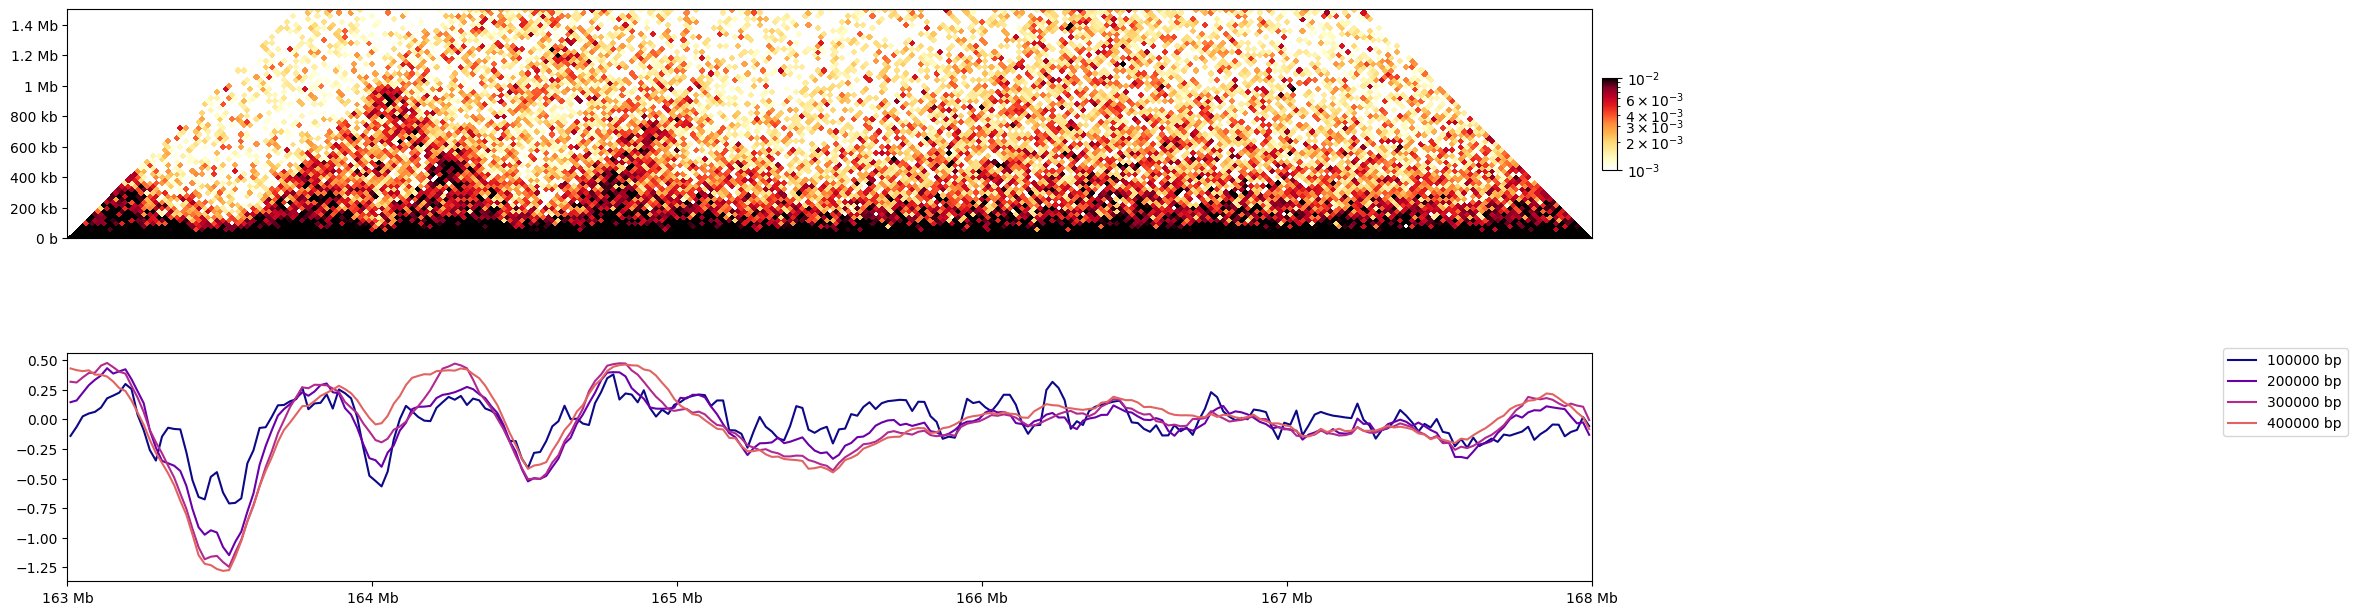

In [30]:
region = ('chr5', 163_000_000, 168_000_000)
norm = LogNorm(vmax=0.01, vmin=0.001)
data = clr.matrix(balance=True).fetch(region)

f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 1500000)
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,6))))

for res in [100000, 200000, 300000, 400000]:
    ins_ax.plot(insul_region[['start', 'end']].mean(axis=1), insul_region[f'log2_insulation_score_{res}'], label=f'{res} bp')
ins_ax.legend(bbox_to_anchor=(1.5, 1.05), loc='upper right')

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

### 100 kb and 200 kb window looks reasonable
### Select cutoff for insulation boundaries

In [31]:
insulation = find_boundaries(insulation)

In [32]:
insulation.iloc[1000:1005]

,chrom,start,end,is_bad_bin,log2_insulation_score_100000,n_valid_pixels_100000,log2_insulation_score_200000,n_valid_pixels_200000,log2_insulation_score_300000,n_valid_pixels_300000,log2_insulation_score_400000,n_valid_pixels_400000,boundary_strength_100000,boundary_strength_400000,boundary_strength_200000,boundary_strength_300000
1000,chr5,20000000,20020000,False,0.118446,22.0,-0.111268,97.0,-0.063830,222.0,-0.034433,397.0,NaN,NaN,NaN,NaN
1001,chr5,20020000,20040000,False,0.231938,22.0,-0.075493,97.0,-0.041073,222.0,-0.043641,397.0,NaN,0.009209,NaN,NaN
1002,chr5,20040000,20060000,False,0.179994,22.0,-0.019234,97.0,-0.055890,222.0,-0.027817,397.0,NaN,NaN,NaN,NaN
1003,chr5,20060000,20080000,False,0.089900,22.0,-0.049402,97.0,-0.095658,222.0,-0.015759,397.0,NaN,NaN,NaN,NaN
1004,chr5,20080000,20100000,False,-0.012592,22.0,-0.115459,97.0,-0.116606,222.0,-0.036966,397.0,0.041727,NaN,NaN,NaN


In [33]:
thresholds_li = {}
thresholds_otsu = {}
for w in windows:
    thresholds_li[w] = threshold_li(insulation[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu[w] = threshold_otsu(insulation[f'boundary_strength_{w}'].dropna().values)

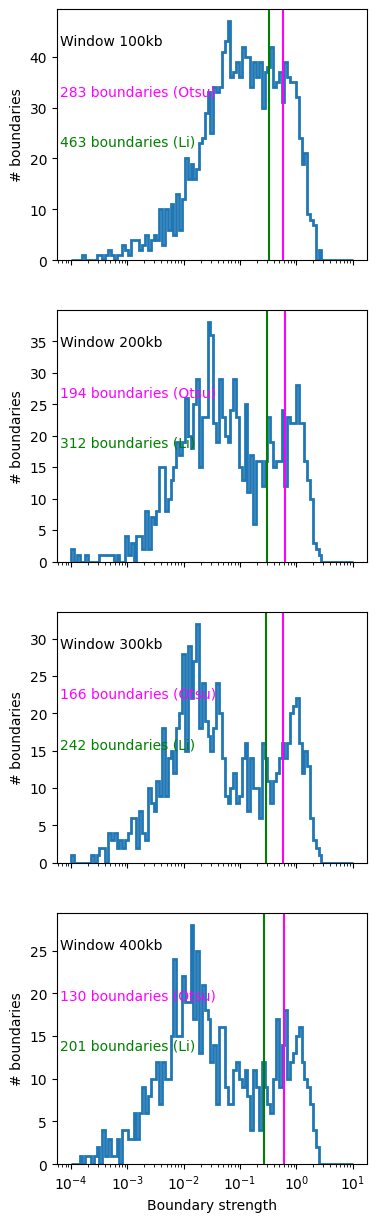

In [35]:
histkwargs = dict(
    bins=10**np.linspace(-4,1,100),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(4,15))

for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation[f'boundary_strength_{w}'],
        **histkwargs
    )
    n_boundaries_li = (insulation[f'boundary_strength_{w}'].dropna()>=thresholds_li[w]).sum()
    n_boundaries_otsu = (insulation[f'boundary_strength_{w}'].dropna()>=thresholds_otsu[w]).sum()
    ax.axvline(thresholds_li[w], c='green')
    ax.axvline(thresholds_otsu[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');

(111000000.0, 118000000.0)

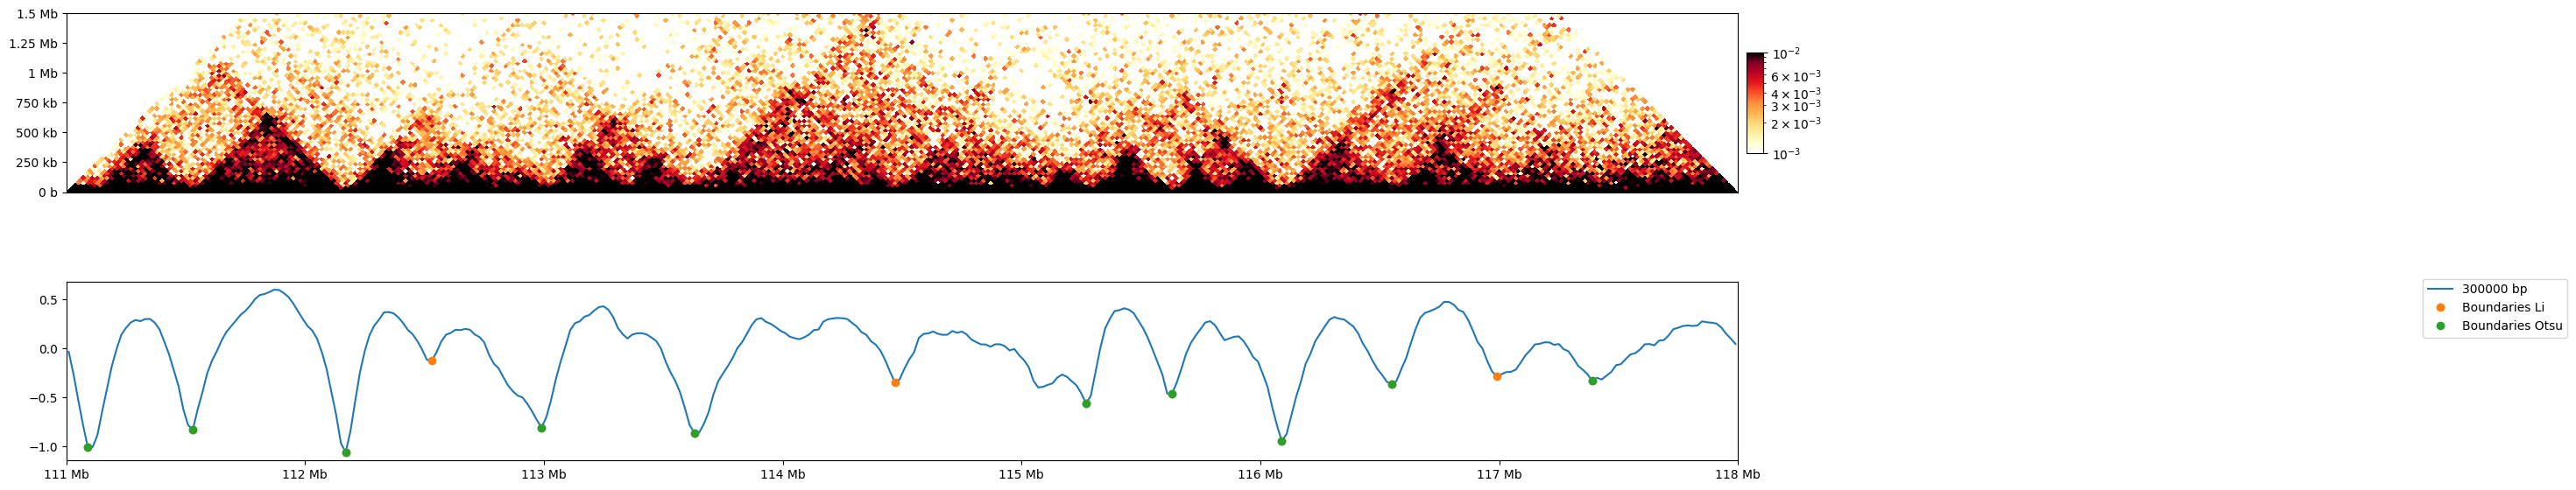

In [47]:
res = 300000
region = ('chr5', 111_000_000, 118_000_000)
norm = LogNorm(vmax=0.01, vmin=0.001)
data = clr.matrix(balance=True).fetch(region)

f, ax = plt.subplots(figsize=(25, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 1500000)
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1), insul_region[f'log2_insulation_score_{res}'], label=f'{res} bp')
#boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{res}'])]
#ins_ax.plot(boundaries[['start', 'end']].mean(axis=1), boundaries[f'log2_insulation_score_{res}'], 'o', label='Boundaries')
boundaries = insul_region[insul_region[f'boundary_strength_{res}'] >=thresholds_li[res]]
ins_ax.plot(boundaries[['start', 'end']].mean(axis=1), boundaries[f'log2_insulation_score_{res}'], 'o', label='Boundaries Li')
boundaries = insul_region[insul_region[f'boundary_strength_{res}'] >=thresholds_otsu[res]]
ins_ax.plot(boundaries[['start', 'end']].mean(axis=1), boundaries[f'log2_insulation_score_{res}'], 'o', label='Boundaries Otsu')

ins_ax.legend(bbox_to_anchor=(1.5, 1.05), loc='upper right')

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

## Calculate insulation boundaries for whole genome

### 300kb window, 20kb resolution

In [60]:
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    resolution = 20000
    clr = cooler.Cooler(f'/DATA/users/magnitov/hap_phen/{sample}.hg38.mapq_30.1000.mcool::/resolutions/{resolution}')
    window = 300000
    insulation = calculate_insulation_score(clr, [window], verbose=True)

    # Define insulation boundaries
    insulation = find_boundaries(insulation)
    
    thresholds_li = {}
    thresholds_li[window] = threshold_li(insulation[f'boundary_strength_{window}'].dropna().values)
        
    significant_borders = insulation[insulation[f'boundary_strength_{window}'] >= thresholds_li[window]]
    significant_borders = significant_borders[significant_borders['is_bad_bin'] == False]
    significant_borders[['chrom', 'start', 'end']].to_csv(f'./insulation/{sample}.insulation_boundaries.bed', sep = '\t', header = 0, index = 0)

    # Define TADs
    chrom_sizes = pd.read_csv('/DATA/users/magnitov/genomes/hg38.chrom.sizes', sep = '\t', header = None)
    tads = []
    for chromosome in np.unique(significant_borders['chrom']):
        cbs = significant_borders[significant_borders['chrom'] == chromosome]
        for i in range(0, len(cbs)):
            if i == 0:
                end = cbs.values[i][1:3][random.randint(0, 1)]
                tads.append([chromosome, 0, end])
            elif i == len(cbs)-1:
                start = end
                tads.append([chromosome, end, chrom_sizes[chrom_sizes[0] == chromosome][1].values[0]])
            else:
                start = end
                end = cbs.values[i][1:3][random.randint(0, 1)]
                tads.append([chromosome, start, end])
                
    tads = pd.DataFrame(tads)
    tads.to_csv(f'./insulation/{sample}.tads.bed', sep = '\t', header = 0, index = 0)

INFO:root:Processing chr1
INFO:root:Processing chr2
INFO:root:Processing chr3
INFO:root:Processing chr4
INFO:root:Processing chr5
INFO:root:Processing chr6
INFO:root:Processing chr7
INFO:root:Processing chr8
INFO:root:Processing chr9
INFO:root:Processing chr10
INFO:root:Processing chr11
INFO:root:Processing chr12
INFO:root:Processing chr13
INFO:root:Processing chr14
INFO:root:Processing chr15
INFO:root:Processing chr16
INFO:root:Processing chr17
INFO:root:Processing chr18
INFO:root:Processing chr19
INFO:root:Processing chr20
INFO:root:Processing chr21
INFO:root:Processing chr22
INFO:root:Processing chrX
INFO:root:Processing chrY
INFO:root:Processing chrM
INFO:root:Processing chr1
INFO:root:Processing chr2
INFO:root:Processing chr3
INFO:root:Processing chr4
INFO:root:Processing chr5
INFO:root:Processing chr6
INFO:root:Processing chr7
INFO:root:Processing chr8
INFO:root:Processing chr9
INFO:root:Processing chr10
INFO:root:Processing chr11
INFO:root:Processing chr12
INFO:root:Processing c